In [42]:
# O arquivo .data é basicamente um csv sem cabeçalho, o que significa que temos que criar um
# acredito que posicoes de 1-9 como cabecalho sao a melhor opcao
import pandas as pd
colunas = [f"pos_{i}" for i in range(1, 10)] + ["classe"]

df = pd.read_csv("../../data/raw/tic-tac-toe.data", header=None, names=colunas)
df.head()

,pos_1,pos_2,pos_3,pos_4,pos_5,pos_6,pos_7,pos_8,pos_9,classe
0,x,x,x,x,o,o,x,o,o,positive
1,x,x,x,x,o,o,o,x,o,positive
2,x,x,x,x,o,o,o,o,x,positive
3,x,x,x,x,o,o,o,b,b,positive
4,x,x,x,x,o,o,b,o,b,positive


In [43]:
df.duplicated(subset=[f'pos_{i}' for i in range(1,10)]).any()

np.False_

In [44]:
print(f'Classes ->  {list(df['classe'].unique())}')
print('positive X VENCEU')
print('negative O VENCEU')

Classes ->  ['positive', 'negative']
positive X VENCEU
negative O VENCEU


In [45]:
display(df.describe())
display(df.drop('classe', axis=1).apply(pd.Series.value_counts).fillna(0))
display(df['classe'].value_counts())

df_encoded = pd.get_dummies(df.drop('classe', axis=1))

df_encoded['classe'] = df['classe'].map({'positive': 1, 'negative': 0})

correlacao = df_encoded.corr()['classe'].sort_values(ascending=False)
print(correlacao)

,pos_1,pos_2,pos_3,pos_4,pos_5,pos_6,pos_7,pos_8,pos_9,classe
count,958,958,958,958,958,958,958,958,958,958
unique,3,3,3,3,3,3,3,3,3,2
top,x,x,x,x,x,x,x,x,x,positive
freq,418,378,418,378,458,378,418,378,418,626


,pos_1,pos_2,pos_3,pos_4,pos_5,pos_6,pos_7,pos_8,pos_9
x,418,378,418,378,458,378,418,378,418
o,335,330,335,330,340,330,335,330,335
b,205,250,205,250,160,250,205,250,205


classe
positive    626
negative    332
Name: count, dtype: int64

classe     1.000000
pos_5_x    0.292997
pos_1_x    0.096689
pos_7_x    0.096689
pos_9_x    0.096689
pos_3_x    0.096689
pos_4_o    0.061686
pos_2_o    0.061686
pos_8_o    0.061686
pos_6_o    0.061686
pos_5_b    0.043806
pos_2_b    0.043150
pos_4_b    0.043150
pos_6_b    0.043150
pos_8_b    0.043150
pos_9_b    0.043023
pos_3_b    0.043023
pos_1_b    0.043023
pos_7_b    0.043023
pos_8_x   -0.098745
pos_4_x   -0.098745
pos_2_x   -0.098745
pos_6_x   -0.098745
pos_7_o   -0.137554
pos_3_o   -0.137554
pos_9_o   -0.137554
pos_1_o   -0.137554
pos_5_o   -0.340025
Name: classe, dtype: float64


### Interpretação

Temos 9 posições no tabuleiro, cada uma com 3 possíveis valores:

- `x` → jogada do X  
- `o` → jogada do O  
- `b` → posição vazia  

---

**Observação:**  
Em todas as posições (1–9), `x` tem a maior frequência.  
Isso pode ser explicado pelo fato de que, normalmente, o jogador `X` faz a primeira jogada.

---

### Correlação importante

Existe uma correlação relevante na posição central (`pos_5`):

- **Negativa**:
  - Quando `o` joga na posição 5 (centro), aumenta a chance de derrota (classe `negative`)

- **Positiva**:
  - Quando `x` joga na posição 5 (centro), aumenta a chance de vitória (classe `positive`)

---

### Classes do problema

Temos duas classes possíveis:

- `positive` → quando `x` ganha  
- `negative` → quando `o` ganha  

---

### Distribuição dos dados

Total de amostras: **958**

- `positive`: 626 (~65%)  
- `negative`: 332 (~35%)  

---

### Conclusão

Os dados apresentam um **leve desbalanceamento**, com predominância da classe `positive`.

## Analisando o dataset só temos duas classes Positive e Negative, o que gerou uma dúvida: O dataset não tem casos de empate?

O código abaixo verificas as jogas em cada posicao do tabuleiro para criar uma nova coluna de classificacao e verificar se realmente não existe empate no dataset ou se ele esta mal categorizado

In [46]:

vitorias = [
    [0,1,2], [3,4,5], [6,7,8],  
    [0,3,6], [1,4,7], [2,5,8],  
    [0,4,8], [2,4,6]            
]
def classificar(tabuleiro):
    for comb in vitorias:
        a, b, c = comb
        
        if tabuleiro[a] == tabuleiro[b] == tabuleiro[c]:
            if tabuleiro[a] == 'x':
                return 'X venceu'
            elif tabuleiro[a] == 'o':
                return 'X venceu'

    if 'b' not in tabuleiro:
        return 'Empate'
    
    return 'Em andamento'


def classificar_linha(row):
    tabuleiro = row.values.tolist()
    return classificar(tabuleiro)

df['resultado'] = df.drop('classe', axis=1).apply(classificar_linha, axis=1)

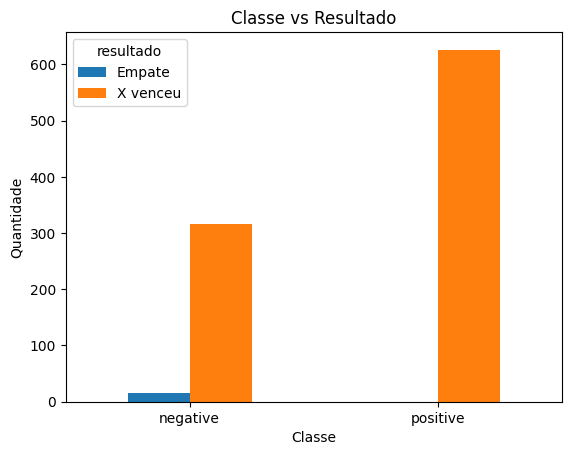

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# tabela de frequências cruzadas
freq = pd.crosstab(df['classe'], df['resultado'])

# plot
freq.plot(kind='bar')

plt.title('Classe vs Resultado')
plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.show()

Com a nova coluna de resultados, identificamos que existe sim situacoes de empate. 
Verificando mais a fundo que classe o dataset original classificava como empate, encontramos que em toda a situcao de empate era classificada como Negative, o que sugere que a classe do dataset era uma variavel binaria para vitoria de X. O que reafirma mais ainda o desbalanceamento no dataset, a seguir vamos mostrar um grafico de como os novos resultados -> X, O e empate se distribuem

resultado
X venceu    942
Empate       16
Name: count, dtype: int64

<Axes: >

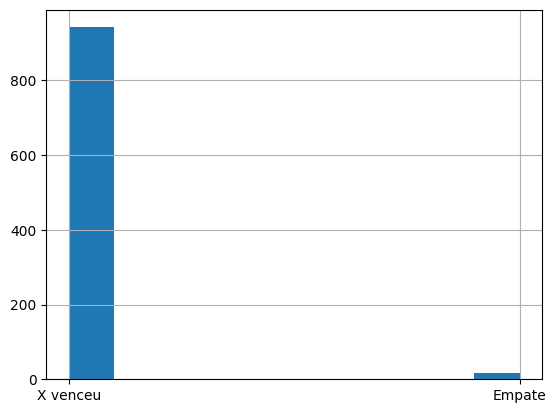

In [48]:
display(df['resultado'].value_counts())
df['resultado'].hist()

Em um jogo real de tic tac toe, só existem 32 possibilidades de empate, nos dados do dataset temos 16 delas, podemos obter as outras espelhando as posicoes (onde é X vira O e vice versa)


Temos 3 classes ate agora (X, O, EMPATE), porém o trabalho pede 4 classes:
- **Tem jogo**
- **Jogador X venceu**
- **Jogador O venceu**
- **Empate**

A classe faltante 'Tem jogo' nao esta presente no dataset pois acontece quando alguma posicao tem um espcao vazio e nao ocorreu vitoria nem de X nem de O.

A seguir vamos elaborar uma forma de se obter essa nova classe

In [49]:
df['classe'] = df['resultado']
df.drop('resultado', inplace=True, axis=1)
df.to_csv('../../data/processed/eda_1.csv', index=False)
df

,pos_1,pos_2,pos_3,pos_4,pos_5,pos_6,pos_7,pos_8,pos_9,classe
0,x,x,x,x,o,o,x,o,o,X venceu
1,x,x,x,x,o,o,o,x,o,X venceu
2,x,x,x,x,o,o,o,o,x,X venceu
3,x,x,x,x,o,o,o,b,b,X venceu
4,x,x,x,x,o,o,b,o,b,X venceu
...,...,...,...,...,...,...,...,...,...,...
953,o,x,x,x,o,o,o,x,x,Empate
954,o,x,o,x,x,o,x,o,x,Empate
955,o,x,o,x,o,x,x,o,x,Empate
956,o,x,o,o,x,x,x,o,x,Empate
